In [387]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import (
    CXGate,
    RZXGate,
    UGate,
    UnitaryGate,
    XXPlusYYGate,
    iSwapGate,
)
from qiskit.circuit.random import random_circuit
from qiskit.quantum_info import Operator, average_gate_fidelity
from qiskit.quantum_info.random import random_unitary
from qiskit.transpiler import (
    InstructionProperties,
    PassManager,
    Target,
    generate_preset_pass_manager,
)
from qiskit.transpiler.passes import Optimize1qGatesDecomposition
from tqdm import tqdm
from weylchamber import c1c2c3

from gulps.gulps_synthesis import GulpsDecomposer
from gulps.utils.invariants import GateInvariants
from gulps.synthesis_pass import GulpsDecompositionPass

# from gulps.synthesis_plugin import GulpsSynthesisPlugin

[autoreload of gulps.linear_program failed: Traceback (most recent call last):
  File "/home/evm9/hetero_isas/.venv/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
  File "/home/evm9/hetero_isas/.venv/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 580, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/importlib/__init__.py", line 131, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 866, in _exec
  File "<frozen importlib._bootstrap_external>", line 995, in exec_module
  File "<frozen importlib._bootstrap>", line 488, in _call_with_frames_removed
  File "/home/evm9/hetero_isas/src/gulps/linear_program.py", line 13, in <module>
    from gulps.utils.qlr import len_qlr, qlr_inequalities, rho_qlr_inequalities
ImportError: cannot import name 'rho_qlr_inequalities' from 'gulps.utils.qlr' (/home/evm9/het

### Usage as a Decomposer

In [388]:
gate_set = [
    # # CXGate(),
    CXGate().power(1 / 2),
    # iSwapGate().power(1 / 2),
    # iSwapGate().power(1 / 3),
]

costs = [1.0]  # , 1 / 2, 1 / 2, 1 / 3]
decomposer = GulpsDecomposer(gate_set, costs, precompute_polytopes=1)

In [389]:
# decomposer.isa.gate_set[0]._monodromy = (0.375, 0.375, 0.375)

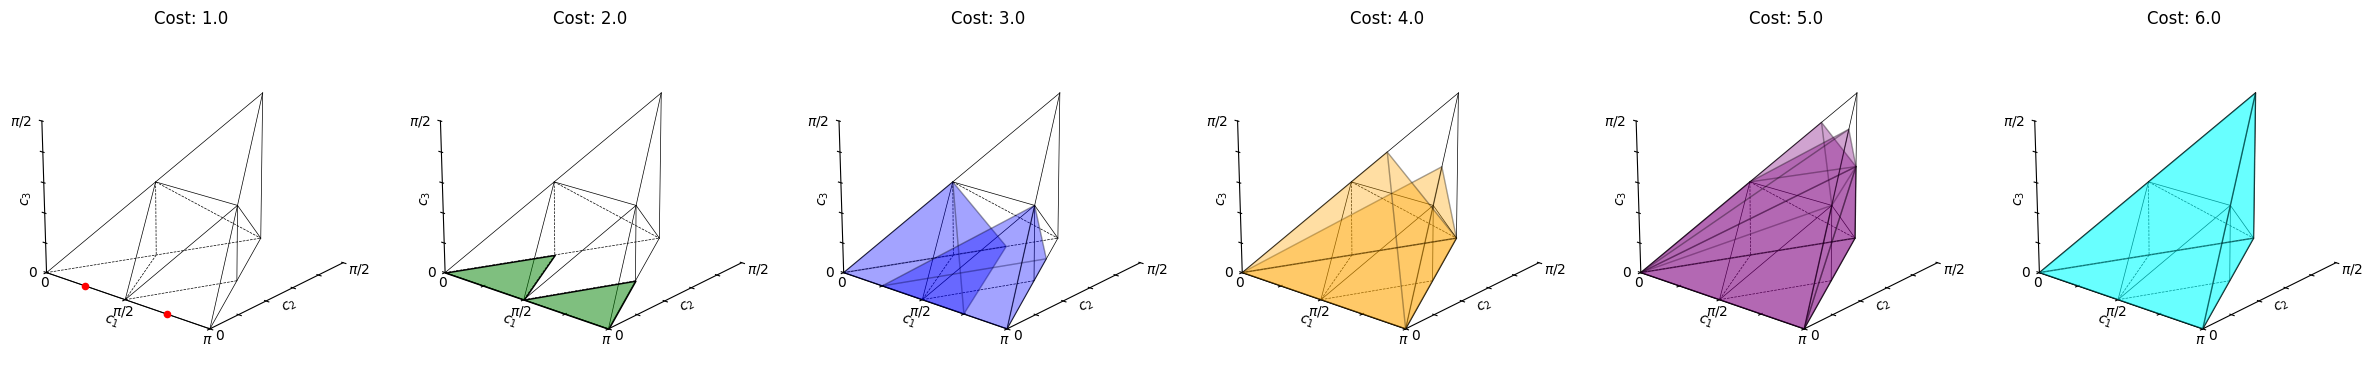

In [390]:
from monodromy.render import _plot_coverage_set

_plot_coverage_set(decomposer.isa.coverage_set)

In [391]:
from monodromy.haar import expected_cost

expected_cost(decomposer.isa.coverage_set)

3.5402548208080247

In [392]:
N = 10_000
hit_rate = {}  # sentence -> count
for idx in tqdm(range(N)):
    u = random_unitary(4, seed=idx)
    working_target = GateInvariants.from_unitary(u)
    sentence = decomposer.isa.polytope_lookup(working_target)
    if sentence is None:
        working_target = working_target.rho_reflect()
        sentence = decomposer.isa.polytope_lookup(working_target)
    if sentence is not None:
        # print(f"Found sentence for {working_target.monodromy}:\n{sentence}")
        hit_rate[tuple(sentence)] = hit_rate.get(tuple(sentence), 0) + 1


  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [00:02<00:00, 4346.90it/s]


In [393]:
hit_rate

{(<gulps.utils.invariants.GateInvariants at 0x7f2518414200>,
  <gulps.utils.invariants.GateInvariants at 0x7f2518414200>): 4559,
 (<gulps.utils.invariants.GateInvariants at 0x7f2518414200>,
  <gulps.utils.invariants.GateInvariants at 0x7f2518414200>): 5090,
 (<gulps.utils.invariants.GateInvariants at 0x7f2518414200>,
  <gulps.utils.invariants.GateInvariants at 0x7f2518414200>): 350,
 (<gulps.utils.invariants.GateInvariants at 0x7f2518414200>,
  <gulps.utils.invariants.GateInvariants at 0x7f2518414200>): 1}

In [394]:
cost = 0
for k, v in hit_rate.items():
    cost += v * len(k)
cost /= N
cost

3.5262

In [395]:
from tqdm import tqdm
import sys

N = 10_000
hit_rate = {}  # sentence -> count
for idx in tqdm(range(N)):
    u = random_unitary(4, seed=idx)
    working_target = GateInvariants.from_unitary(u)
    for sentence in decomposer.isa.enumerate(max_depth=8):
        if sum(gate.strength for gate in sentence) < working_target.strength:
            continue
        sentence_out, intermediates = decomposer._try_lp(sentence, working_target)
        if sentence_out is not None:
            break
    if sentence_out is not None:
        # print(f"Found sentence for {working_target.monodromy}:\n{sentence}")
        hit_rate[tuple(sentence_out)] = hit_rate.get(tuple(sentence_out), 0) + 1
    if sentence_out is None:
        continue
        # print(
        #     f"{idx}: No valid sentence found for {working_target.monodromy}.",
        #     file=sys.stderr,
        # )

  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [00:42<00:00, 234.89it/s]


In [396]:
hit_rate

{(<gulps.utils.invariants.GateInvariants at 0x7f2518414200>,
  <gulps.utils.invariants.GateInvariants at 0x7f2518414200>): 4323,
 (<gulps.utils.invariants.GateInvariants at 0x7f2518414200>,
  <gulps.utils.invariants.GateInvariants at 0x7f2518414200>): 2260,
 (<gulps.utils.invariants.GateInvariants at 0x7f2518414200>,
  <gulps.utils.invariants.GateInvariants at 0x7f2518414200>): 1755,
 (<gulps.utils.invariants.GateInvariants at 0x7f2518414200>,
  <gulps.utils.invariants.GateInvariants at 0x7f2518414200>): 3}

In [397]:
sum(hit_rate.values())

8341

In [398]:
cost = 0
for k, v in hit_rate.items():
    cost += v * len(k)
cost /= N
cost

3.3875

In [409]:
from gulps.utils.invariants import GateInvariants
from qiskit.circuit.library import SwapGate
from monodromy.static.qlr_table import generate_qlr_inequalities

u = CXGate().power(1 / 2)
gi = GateInvariants.from_unitary(u)
gi.logspec

(0.12500000000000014,
 0.12500000000000014,
 -0.12500000000000014,
 -0.12500000000000014)

In [400]:
gi.rho_reflect().monodromy

(0.3749999999999999, 0.3749999999999999, -0.3749999999999999)

In [412]:
# Canonical comparison
from monodromy.coordinates import monodromy_to_positive_canonical_coordinate

canon = monodromy_to_positive_canonical_coordinate(*gi.monodromy)
rho_canon = monodromy_to_positive_canonical_coordinate(*gi.rho_reflect().monodromy)
rho_canon

(1.178097245096172, 0.0, 0.0)

In [413]:
rho_canon

(1.178097245096172, 0.0, 0.0)

In [401]:
from monodromy.coordinates import rho_reflect

rho_reflect(decomposer.isa.coverage_set[1])

Polytope(convex_subpolytopes=[ConvexPolytope(inequalities=[[2, 0, 0, 0]], equalities=[[2, 0, 0, 16], [2, -16, -16, -16], [-2, 16, 0, 0]], name='anonymous_convex_polytope_556'), ConvexPolytope(inequalities=[[2, 0, 0, 0]], equalities=[[6, 0, 0, 16], [6, -16, -16, -16], [-6, 16, 0, 0]], name='anonymous_convex_polytope_557')])

In [402]:
decomposer.isa.coverage_set[1].convex_subpolytopes

[ConvexPolytope(inequalities=[[1, 0, 0, 0]], equalities=[[-3, 8, 0, 0], [-3, 0, 8, 0], [3, 0, 0, 8]], name='True ∩ QLR relations ∩ A_SU(4)^monodromy ∩ A_SU(4)^monodromy ∩ A_SU(4)^monodromy ∩ True ∩ QLR relations ∩ A_SU(4)^monodromy ∩ A_SU(4)^monodromy ∩ A_SU(4)^monodromy ∩ origin ∩ anonymous_convex_polytope_530 ∩ True ∩ A_PU(4)^monodromy ∩ A_PU(4)^monodromy ∩ origin'),
 ConvexPolytope(inequalities=[[1, 0, 0, 0]], equalities=[[-1, 8, 0, 0], [-1, 0, 8, 0], [1, 0, 0, 8]], name='True ∩ QLR relations ∩ A_SU(4)^monodromy ∩ A_SU(4)^monodromy ∩ A_SU(4)^monodromy ∩ anonymous_convex_polytope_531 ∩ A_SU(4)^monodromy ∩ A_SU(4)^monodromy ∩ A_SU(4)^monodromy ∩ origin ∩ anonymous_convex_polytope_530 ∩ True ∩ A_PU(4)^monodromy ∩ A_PU(4)^monodromy ∩ origin')]

In [403]:
rho_reflect(decomposer.isa.coverage_set[1]).convex_subpolytopes

[ConvexPolytope(inequalities=[[2, 0, 0, 0]], equalities=[[2, 0, 0, 16], [2, -16, -16, -16], [-2, 16, 0, 0]], name='anonymous_convex_polytope_558'),
 ConvexPolytope(inequalities=[[2, 0, 0, 0]], equalities=[[6, 0, 0, 16], [6, -16, -16, -16], [-6, 16, 0, 0]], name='anonymous_convex_polytope_559')]

^ Debugging

In [376]:
N = 1
for idx in tqdm(range(N)):
    u = random_unitary(4, seed=12)
    v = Operator(decomposer(u))
    fid = average_gate_fidelity(u, v)
    if fid < 0.9999:
        print(f"Unitary {idx} fidelity is low: {fid:.4f}")
        print(c1c2c3(u), c1c2c3(v))
        print("\n")
qc = decomposer(u)
qc.draw()

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [03:28<?, ?it/s]


RuntimeError: LP failed for precomputed ISA sentence.

In [ ]:
import cProfile

u = random_unitary(4, seed=0)
cProfile.run("decomposer._run(u)", "profile_timings/tempg.prof")


### Usage as a TransformationPass

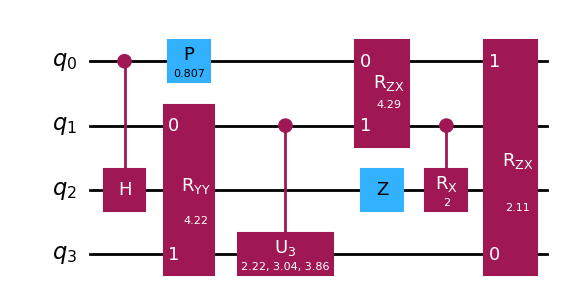

NotImplementedError: trivial edge case

In [ ]:
input_qc = random_circuit(
    4, 4, max_operands=2, num_operand_distribution={1: 0.2, 2: 0.8}
)
display(input_qc.draw("mpl"))

pm = PassManager(
    [
        GulpsDecompositionPass(gate_set, costs),
        Optimize1qGatesDecomposition(),
    ]
)
output_qc = pm.run(input_qc)
output_qc.draw("mpl", fold=-1)

### Usage as a Unitary Synthesis Plugin

In [ ]:
# check that the plugin is installed
from qiskit.transpiler.passes.synthesis import unitary_synthesis_plugin_names

unitary_synthesis_plugin_names()

['gulps', 'aqc', 'clifford', 'default', 'sk']

In [ ]:
# create some mock hetereogeneous ISA backend
target = Target()

target.add_instruction(
    RZXGate(np.pi / 2),
    {
        (0, 1): InstructionProperties(
            duration=100,
            error=0.01,
        )
    },
    name="cx",
)
target.add_instruction(
    RZXGate(np.pi / 4),
    {
        (0, 1): InstructionProperties(
            duration=50,
            error=0.05,
        )
    },
    name="scx",
)

target.add_instruction(
    XXPlusYYGate(np.pi),
    {
        (0, 1): InstructionProperties(
            duration=200,
            error=0.02,
        )
    },
    name="iswap",
)
target.add_instruction(
    XXPlusYYGate(np.pi / 2),
    {
        (0, 1): InstructionProperties(
            duration=100,
            error=0.01,
        )
    },
    name="siswap",
)

theta = Parameter("theta")
phi = Parameter("phi")
lam = Parameter("lambda")
u_props = {
    (0,): InstructionProperties(duration=0, error=0),
    (1,): InstructionProperties(duration=0, error=0),
}
target.add_instruction(UGate(theta, phi, lam), u_props)

In [ ]:
circuit = QuantumCircuit(2)
# circuit.cx(0, 1)
circuit.append(UnitaryGate(Operator(CXGate())), [0, 1])

pass_manager = generate_preset_pass_manager(
    optimization_level=3,
    target=target,
    translation_method="synthesis",
    unitary_synthesis_method="gulps",
)

out = pass_manager.run(circuit)
out.draw("mpl")

TranspilerError: 'HighLevelSynthesis is unable to synthesize "cx"'